Načteno 7 klidových a 6 zátěžových záznamů
Délka záznamu: 15.0 s, vzorkovací frekvence: 360 Hz


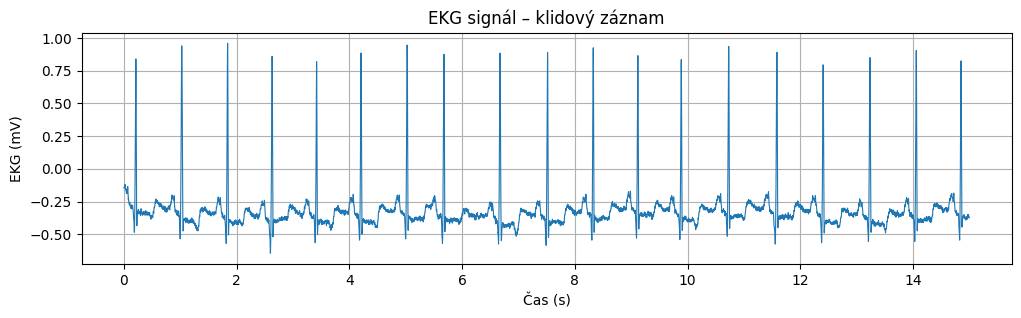

In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt

# seznamy souborů
files_klid  = sorted(glob.glob("ekg_klid/*.txt"))
files_zatez = sorted(glob.glob("ekg_zatez/*.txt"))

# načtení prvního záznamu
data0 = np.loadtxt(files_klid[0], skiprows=1)
t   = data0[:, 0]
ekg = data0[:, 1]

print(f"Načteno {len(files_klid)} klidových a {len(files_zatez)} zátěžových záznamů")
print(f"Délka záznamu: {t[-1]:.1f} s, vzorkovací frekvence: {1/(t[1]-t[0]):.0f} Hz")

# vykreslení
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, ekg, linewidth=0.8)
ax.set_xlabel("Čas (s)")
ax.set_ylabel("EKG (mV)")
ax.set_title("EKG signál – klidový záznam")
ax.grid(True)
plt.show()

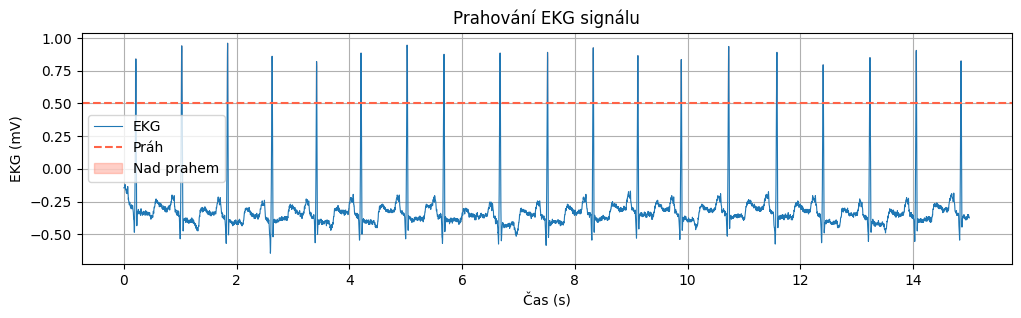

In [2]:
PRAH = 0.5

nad_prahem = ekg > PRAH

fig, ax = plt.subplots(figsize=(12, 3))

ax.plot(t, ekg, linewidth=0.8, label="EKG")
ax.axhline(PRAH, color="tomato", linestyle="--", label="Práh")

ax.fill_between(t, PRAH, ekg, where=nad_prahem,
                alpha=0.3, color="tomato", label="Nad prahem")

ax.set_xlabel("Čas (s)")
ax.set_ylabel("EKG (mV)")
ax.set_title("Prahování EKG signálu")
ax.legend()
ax.grid(True)

plt.show()

Nalezeno vrcholů: 19


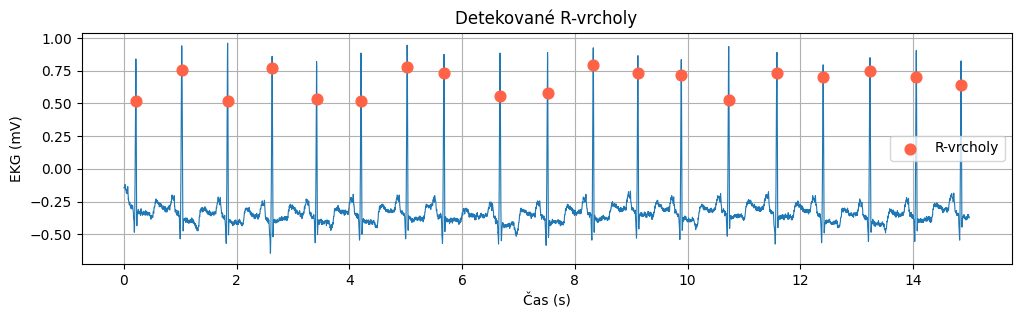

In [3]:
# detekce sestupné hrany
vrcholy = nad_prahem & ~np.roll(nad_prahem, -1)
vrcholy[-1] = False  # oprava okraje

vrcholy_idx = np.where(vrcholy)[0]

print(f"Nalezeno vrcholů: {len(vrcholy_idx)}")

# vykreslení
fig, ax = plt.subplots(figsize=(12, 3))

ax.plot(t, ekg, linewidth=0.8)
ax.scatter(t[vrcholy_idx], ekg[vrcholy_idx],
           color="tomato", s=60, zorder=5, label="R-vrcholy")

ax.set_xlabel("Čas (s)")
ax.set_ylabel("EKG (mV)")
ax.set_title("Detekované R-vrcholy")
ax.legend()
ax.grid(True)

plt.show()

In [4]:
cas_vrcholu  = t[vrcholy_idx]
rr_intervaly = np.diff(cas_vrcholu)

tf_bpm = 60 / rr_intervaly.mean()

print(f"Průměrný R-R interval: {rr_intervaly.mean():.3f} s")
print(f"Tepová frekvence: {tf_bpm:.1f} BPM")

Průměrný R-R interval: 0.813 s
Tepová frekvence: 73.8 BPM


Klidová TF (BPM):  ['73.8', '67.0', '62.0', '65.0', '68.0', '63.0', '67.0']
Zátěžová TF (BPM): ['65.7', '98.0', '103.0', '107.0', '95.0', '101.0']


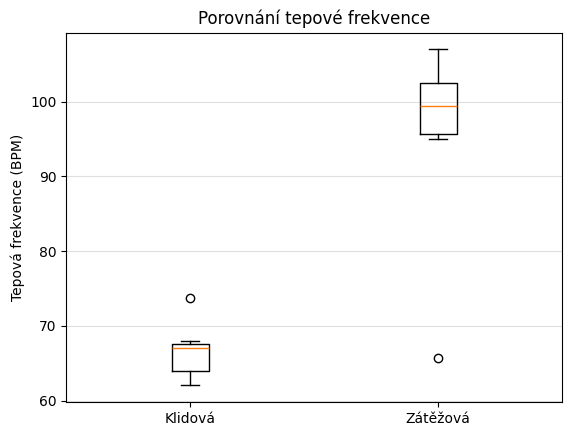

In [5]:
PRAH = 0.5

def spocitej_tf(soubor):
    data = np.loadtxt(soubor, skiprows=1)
    t = data[:, 0]
    ekg = data[:, 1]

    nad_prahem = ekg > PRAH

    vrcholy = nad_prahem & ~np.roll(nad_prahem, -1)
    vrcholy[-1] = False

    vrcholy_idx = np.where(vrcholy)[0]

    cas_vrcholu = t[vrcholy_idx]

    if len(cas_vrcholu) < 2:
        return np.nan  # ochrana proti chybě

    rr = np.diff(cas_vrcholu)
    return 60 / rr.mean()

# výpočty
tf_klid  = [spocitej_tf(f) for f in files_klid]
tf_zatez = [spocitej_tf(f) for f in files_zatez]

print("Klidová TF (BPM): ", [f"{x:.1f}" for x in tf_klid])
print("Zátěžová TF (BPM):", [f"{x:.1f}" for x in tf_zatez])

# boxplot
fig, ax = plt.subplots()

ax.boxplot([tf_klid, tf_zatez],
           tick_labels=["Klidová", "Zátěžová"])

ax.set_ylabel("Tepová frekvence (BPM)")
ax.set_title("Porovnání tepové frekvence")
ax.grid(True, axis="y", alpha=0.4)

plt.show()

# Rozdíl mezi skupinami:
Zátěžová skupina má výrazně vyšší tepovou frekvenci (~95–110 BPM) než klidová (~60–70 BPM), což je jasně vidět i na boxplotu.

# Outliery:
Může se objevit odlehlá hodnota, např. kvůli:

arytmii (nepravidelný rytmus)
šumu v signálu
špatně zvolenému prahu (detekce falešných vrcholů)

# Omezení metody:
Jednoduché prahování + sestupná hrana:

nefunguje dobře při šumu
selhává při změně amplitudy signálu
neumí adaptovat práh

# Jak to zlepšit:

filtrace signálu (band-pass filtr ~5–15 Hz)
adaptivní práh
detekce maxima místo hran
pokročilé metody (např. Pan–Tompkins algoritmus)